In [16]:
import pandas as pd
from os.path import join


df = pd.read_csv(join("", "/run/media/ki/data/datasets/celeba/list_attr_celeba.csv"))

In [17]:
df

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202594,202595.jpg,-1,-1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1
202595,202596.jpg,-1,-1,-1,-1,-1,1,1,-1,-1,...,-1,1,1,-1,-1,-1,-1,-1,-1,1
202596,202597.jpg,-1,-1,-1,-1,-1,-1,-1,-1,1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
202597,202598.jpg,-1,1,1,-1,-1,-1,1,-1,1,...,-1,1,-1,1,1,-1,1,-1,-1,1


In [18]:
del df["image_id"]

In [30]:
df = df.rename(columns={c: c.replace("_", " ") for c in df.columns})

In [31]:
corr = df.corr()

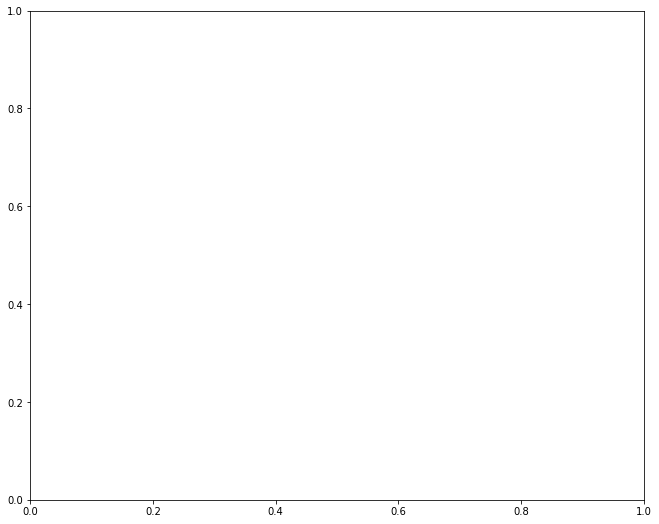

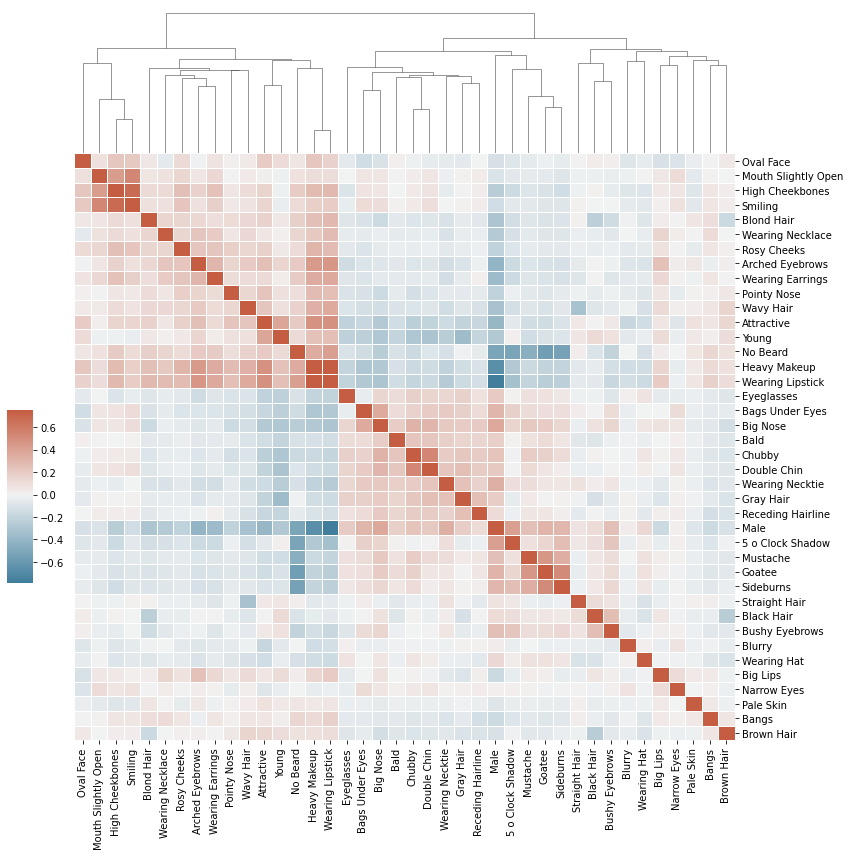

In [38]:
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sb.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
# sb.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
#             square=True, linewidths=.5, cbar_kws={"shrink": .5})

g = sb.clustermap(
    corr,
    cmap=cmap,
    # annot=True,
    # square=True,
    linewidths=0.5,
    center=0,
    vmax=0.75,
    figsize=(12, 12),
    cbar_pos=(0.02, 0.32, 0.03, 0.2),
    dendrogram_ratio=(0.1, 0.2),
)

g.ax_row_dendrogram.remove()
# plt.tight_layout(pad=0)
plt.savefig("/home/ki/correlations.pdf", bbox_inches="tight")

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
from omegaconf import OmegaConf


dfs = []

for exp_num in range(10):
    df = pd.read_csv(f"multirun/2024-12-09/18-23-19/{exp_num}/stats.csv")
    cfg = OmegaConf.load(f"multirun/2024-12-09/18-23-19/{exp_num}/.hydra/config.yaml")

    # fig, ax = plt.subplots(1,1,figsize=(10,10))
    df.reset_index(inplace=True)

    res = []
    for i, r in enumerate(df["data"]):
        if "nan" in r:
            continue

        r = ast.literal_eval(r)
        for d in r:
            d.update({"turn": i})

        res += r

    r = pd.DataFrame(res).reset_index()
    r["delta"] = cfg.min_delta
    r["rules"] = df["constraints:"].apply(lambda x: len(ast.literal_eval(x)))
    dfs.append(r)

df = pd.concat(dfs)

In [149]:
df

,index,loss,AUROC,loss_in,loss_out,turn,delta,rules
0,0,0.038109,0.489217,4.169250,4.131142,0,0.00,0.0
1,1,0.061093,0.482685,4.171627,4.110534,0,0.00,0.0
2,2,0.066010,0.479012,4.170387,4.104376,0,0.00,1.0
3,3,0.079980,0.477391,4.171137,4.091157,0,0.00,2.0
4,4,0.017239,0.505894,4.169339,4.152100,0,0.00,2.0
...,...,...,...,...,...,...,...,...
2935,2935,-2.319670,0.873814,3.253356,5.573026,587,0.45,NaN
2936,2936,-2.355134,0.875397,3.253615,5.608748,587,0.45,NaN
2937,2937,-2.670099,0.905228,3.238557,5.908655,587,0.45,NaN
2938,2938,-2.366500,0.881857,3.244277,5.610778,587,0.45,NaN


In [150]:
# fig, ax = plt.subplots(1,1,figsize=(10,10))
# sb.lineplot(r, x="turn", y="loss_in", label="loss in", hue="exp_num", ax=ax, linestyle="-")
# sb.lineplot(r, x="turn", y="loss_out", label="loss out", hue="exp_num", ax=ax, linestyle="--")
# plt.legend()# labels=["loss_in", "loss_out"]
# plt.show()
#
#

# Enable LaTeX rendering in matplotlib
plt.rcParams.update(
    {
        "text.usetex": True,  # Use LaTeX to render text
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath, amssymb}",  # Load required packages,
        "pdf.fonttype": 42,  # Ensure fonts are stored as Type 42 (TrueType) for best quality in PDFs
        "ps.fonttype": 42,
        "text.usetex": True,  # Use LaTeX for text rendering
        "font.serif": ["Times"],  # Set Times as the default serif font
        "font.size": 24,  # General font size
        "axes.titlesize": 20,  # Title font size
        "axes.labelsize": 18,  # Axis label font size
        "xtick.labelsize": 16,  # X tick label font size
        "ytick.labelsize": 16,  # Y tick label font size
        "legend.fontsize": 14,  # Legend font size
    }
)

/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning

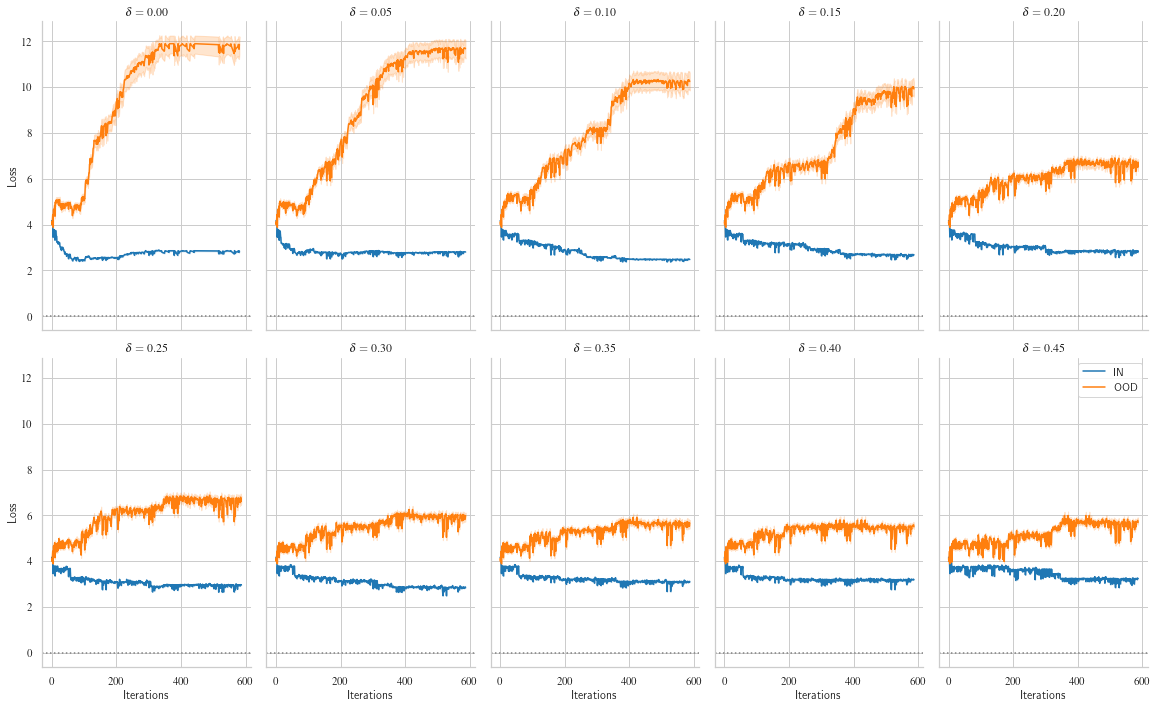

In [155]:
sb.set_theme(style="whitegrid")

grid = sb.FacetGrid(
    df, col="delta", palette="tab20c", col_wrap=5, height=5, aspect=0.65
)

# Draw a line plot to show the trajectory of each random walk
grid.map(sb.lineplot, "turn", "loss_in", label="IN", color="tab:blue")
grid.map(sb.lineplot, "turn", "loss_out", label="OOD", color="tab:orange")

grid.refline(y=0, linestyle=":")

# Format the titles to .2f
grid.set_titles(r"$\delta={col_name:.2f}$")

grid.set_axis_labels("Iterations", "Loss")

grid.fig.subplots_adjust(hspace=0.3, wspace=0.3)

plt.legend()

# Adjust the arrangement of the plots
grid.fig.tight_layout(w_pad=1)

In [ ]:
grid = sb.FacetGrid(
    df, col="delta", palette="tab20c", col_wrap=5, height=5, aspect=0.65
)

# Draw a line plot to show the trajectory of each random walk
grid.map(sb.lineplot, "turn", "AUROC", label="AUROC", color="tab:blue")
grid.set_titles("\delta={col_name:.2f}")
grid.refline(y=0.9179944038391114, linestyle=":", color="tab:red")
plt.legend()

grid.set_axis_labels("Iterations", "AUROC")

grid.fig.subplots_adjust(hspace=0.3, wspace=0.3)


# Adjust the arrangement of the plots
grid.fig.tight_layout(w_pad=1)

#
# fig, ax = plt.subplots(1,1,figsize=(10,10))
# sb.lineplot(r, x="turn", y="AUROC", label="AUROC", ax=ax)
# ax.axhline(y=0.9179944038391114, color='r', linestyle='--', label='Reference Line')
#
# ax.set_ylim([0.8, 0.95])
# plt.show()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

sb.lineplot(data=df.reset_index(), y="rules", x="index", hue="$\delta_{min}$", ax=ax)

ax.set_yscale("log")

In [75]:
import torch
import os
import pandas as pd
from omegaconf import OmegaConf


y = []
x = []

for i in range(0, 10):
    root = f"/home/ki/projects/work/mln-ood/celeb-a/multirun/2025-01-17/12-57-54/{i}"
    f = os.path.join(root, "results-agg.pkl")

    df = pd.read_pickle(f)
    val = df.loc["MLN+Ensemble"]["AUROC", "mean", "mean"]
    y.append(val)

    cfg = OmegaConf.load(os.path.join(root, ".hydra", "config.yaml"))
    le = cfg.ablation_n_rules
    x.append(le)

FileNotFoundError: [Errno 2] No such file or directory: '/home/ki/projects/work/mln-ood/celeb-a/multirun/2025-01-17/12-57-54/8/results-agg.pkl'

Text(0.5, 0, 'Number of rules')

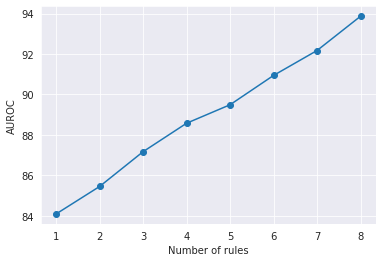

In [78]:
import matplotlib.pyplot as plt

plt.plot(x, y, marker="o")
plt.ylabel("AUROC")
plt.xlabel("Number of rules")

In [19]:
cfg.constraints

['young', 'heavy_makeup implies gray_hair', 'wearing_lipstick implies gray_hair', 'wearing_lipstick implies no_beard', 'smiling implies blond_hair', '(not heavy_makeup) implies young', '(not male) implies no_beard']